In [2]:
import pandas as pd
import dask.dataframe as dd

In [3]:
tf = pd.read_csv("Trips_Full Data.csv")

In [4]:
td = pd.read_csv("Trips_by_Distance.csv")

In [5]:
td.columns = (td.columns.str.strip().str.lower().str.replace(" ","_"))
td = td.fillna(td.mean(numeric_only=True)) # fills missing numeric values with its mean 

In [6]:
# handles missing categorical values
td["state_postal_code"] = td["state_postal_code"].fillna("Unknown")
td["county_name"] = td["county_name"].fillna("Unknown")

In [7]:
tf.columns = (tf.columns.str.strip().str.lower().str.replace(" ","_"))  

In [8]:
td.dtypes

level                              object
date                               object
state_fips                        float64
state_postal_code                  object
county_fips                       float64
county_name                        object
population_staying_at_home        float64
population_not_staying_at_home    float64
number_of_trips                   float64
number_of_trips_<1                float64
number_of_trips_1-3               float64
number_of_trips_3-5               float64
number_of_trips_5-10              float64
number_of_trips_10-25             float64
number_of_trips_25-50             float64
number_of_trips_50-100            float64
number_of_trips_100-250           float64
number_of_trips_250-500           float64
number_of_trips_>=500             float64
row_id                             object
week                                int64
month                               int64
dtype: object

In [9]:
td["date"] = pd.to_datetime(td["date"])

In [10]:
tf["date"] = pd.to_datetime(tf["date"])

In [11]:
tf.isna().sum()

month_of_date                 0
week_of_date                  0
year_of_date                  0
level                         0
date                          0
week_ending_date              0
trips_<1_mile                 0
people_not_staying_at_home    0
population_staying_at_home    0
trips                         0
trips_1-25_miles              0
trips_1-3_miles               0
trips_10-25_miles             0
trips_100-250_miles           0
trips_100+_miles              0
trips_25-100_miles            0
trips_25-50_miles             0
trips_250-500_miles           0
trips_3-5_miles               0
trips_5-10_miles              0
trips_50-100_miles            0
trips_500+_miles              0
dtype: int64

In [12]:
td.isna().sum()            # the output is zero because values were already filled in pre-processing step

level                             0
date                              0
state_fips                        0
state_postal_code                 0
county_fips                       0
county_name                       0
population_staying_at_home        0
population_not_staying_at_home    0
number_of_trips                   0
number_of_trips_<1                0
number_of_trips_1-3               0
number_of_trips_3-5               0
number_of_trips_5-10              0
number_of_trips_10-25             0
number_of_trips_25-50             0
number_of_trips_50-100            0
number_of_trips_100-250           0
number_of_trips_250-500           0
number_of_trips_>=500             0
row_id                            0
week                              0
month                             0
dtype: int64

In [13]:
td.duplicated().sum()

0

In [14]:
tf.duplicated().sum()

0

In [15]:
# filters national level data
national_only = td[td['level'] == "National"]

# classifies into 4 sets based on trip thresholds
set1 = national_only[national_only['number_of_trips_10-25'] > 10000000]
set2 = national_only[national_only['number_of_trips_50-100'] > 10000000]
set3 = national_only[(national_only['number_of_trips_10-25'] > 10000000) & 
                      (national_only['number_of_trips_50-100'] > 10000000)]
set4 = national_only[(national_only['number_of_trips_10-25'] > 10000000) & 
                      (national_only['number_of_trips_50-100'] < 10000000)]

In [16]:
national_data = td[td["level"] == "National"]

weekly_home = national_data.groupby("week")["population_staying_at_home"].mean()
print(weekly_home)

week
0     7.384405e+07
1     7.222715e+07
2     7.144295e+07
3     6.998493e+07
4     6.982941e+07
5     6.910108e+07
6     6.852736e+07
7     7.001310e+07
8     6.587532e+07
9     6.563279e+07
10    6.598210e+07
11    7.366140e+07
12    7.478372e+07
13    7.577730e+07
14    7.568128e+07
15    7.616011e+07
16    7.425262e+07
17    7.430106e+07
18    7.402338e+07
19    7.113875e+07
20    6.735490e+07
21    7.148468e+07
22    7.073767e+07
23    7.030620e+07
24    7.118134e+07
25    6.993038e+07
26    7.264797e+07
27    7.115585e+07
28    7.149897e+07
29    7.425933e+07
30    7.335349e+07
31    7.199460e+07
32    6.848695e+07
33    6.834164e+07
34    7.134600e+07
35    7.371997e+07
36    7.447109e+07
37    7.402661e+07
38    7.317520e+07
39    7.379786e+07
40    7.488744e+07
41    7.417908e+07
42    7.444592e+07
43    7.545111e+07
44    7.847537e+07
45    8.025509e+07
46    8.030774e+07
47    8.110965e+07
48    7.824118e+07
49    7.909777e+07
50    7.997042e+07
51    8.488364e+07
52    8

In [17]:
weekly_not_home = national_data.groupby("week")["population_not_staying_at_home"].mean()
print(weekly_not_home)

week
0     2.528688e+08
1     2.546069e+08
2     2.553911e+08
3     2.568492e+08
4     2.570047e+08
5     2.577330e+08
6     2.583067e+08
7     2.568210e+08
8     2.609588e+08
9     2.612013e+08
10    2.612094e+08
11    2.535301e+08
12    2.524077e+08
13    2.514142e+08
14    2.515102e+08
15    2.510313e+08
16    2.529388e+08
17    2.528904e+08
18    2.531681e+08
19    2.560527e+08
20    2.598366e+08
21    2.557068e+08
22    2.564538e+08
23    2.568853e+08
24    2.560101e+08
25    2.567370e+08
26    2.540195e+08
27    2.555116e+08
28    2.551685e+08
29    2.524081e+08
30    2.533139e+08
31    2.546728e+08
32    2.581805e+08
33    2.583258e+08
34    2.553214e+08
35    2.529475e+08
36    2.521963e+08
37    2.526408e+08
38    2.534922e+08
39    2.528696e+08
40    2.517800e+08
41    2.524883e+08
42    2.522215e+08
43    2.512163e+08
44    2.481921e+08
45    2.464123e+08
46    2.463597e+08
47    2.455578e+08
48    2.484262e+08
49    2.475697e+08
50    2.466970e+08
51    2.417838e+08
52    2

Matplotlib is building the font cache; this may take a moment.


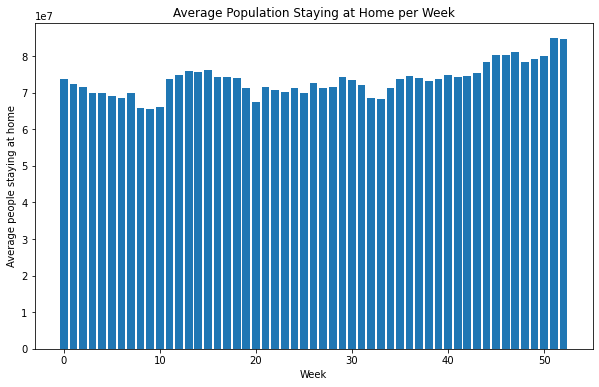

In [18]:
import matplotlib.pyplot as plt

national_data = td[td["level"] == "National"]

weekly_home = national_data.groupby("week")["population_staying_at_home"].mean()

x = weekly_home.index.to_numpy()
y = weekly_home.to_numpy()

plt.figure(figsize=(10,6))
plt.bar(x, y)
plt.xlabel("Week")
plt.ylabel("Average people staying at home")
plt.title("Average Population Staying at Home per Week")
plt.show()